[ 0.00000000e+00+0.00000000e+00j  1.00000000e+00+0.00000000e+00j
  1.00000000e+00+0.00000000e+00j  1.00000000e+00+0.00000000e+00j
 -1.20752763e-16+0.00000000e+00j  9.01295007e-18+0.00000000e+00j
  1.00000000e+00+0.00000000e+00j  5.55111512e-17+0.00000000e+00j
  1.18282348e-16+0.00000000e+00j  9.99416860e-17+0.00000000e+00j
 -6.14513037e-17+0.00000000e+00j -5.90223337e-17+0.00000000e+00j
 -3.24895442e-17+0.00000000e+00j  6.58502847e-18+1.92387495e-17j
  6.58502847e-18-1.92387495e-17j  8.96457214e-18+0.00000000e+00j]
[ 0.00000000e+00+0.00000000e+00j  1.00000000e+00+0.00000000e+00j
  1.00000000e+00+0.00000000e+00j  1.00000000e+00+0.00000000e+00j
 -1.20752763e-16+0.00000000e+00j  9.01295007e-18+0.00000000e+00j
  1.00000000e+00+0.00000000e+00j  5.55111512e-17+0.00000000e+00j
  1.18282348e-16+0.00000000e+00j  9.99416860e-17+0.00000000e+00j
 -6.14513037e-17+0.00000000e+00j -5.90223337e-17+0.00000000e+00j
 -3.24895442e-17+0.00000000e+00j  6.58502847e-18+1.92387495e-17j
  6.58502847e-18-1.92387

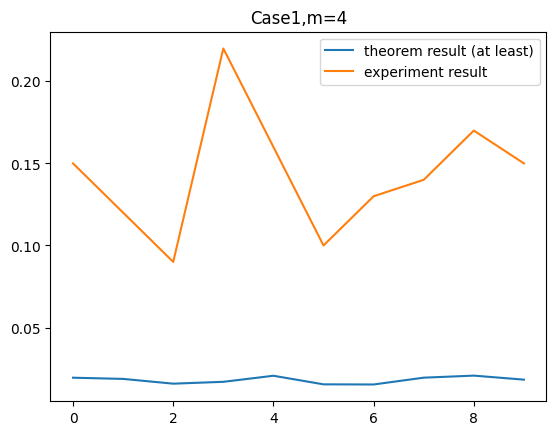

In [2]:
from event_learning_fuc import event_learning
from tools import print_progress,generate_random_statevector,generate_random_projector, generate_rank_n_projector
import numpy as np
import matplotlib.pyplot as plt
import os
############################### Initialization ######################################################

d = 16                             # Dimension of the initial state (need to be a power of 2)
m_s=[4]                  # the number of elements in the povm measurement
case_s=[1]                       # the case to test
          
# num_shot=1                  # the shot for sampling in one circuit
test_time=100                   # the number of times to run the circuit
rank=4                             # the rank of the projector
event_learning_times=10          # run event learning several times 

state_random=True                 # generate the random state
projector_random=False           #generate the random projector to be the base of the povm

dir_name="d_16_fix_state_fix_each__projector_special_07"       # set the directory saving the plot
if not os.path.exists(dir_name):
        os.makedirs(dir_name)

############################# random state ###########################################################


if state_random:
    state=np.array([generate_random_statevector(d)])
else:
    state=np.array([[0,1]])            # manually initialize the state

if projector_random:
    projector_case_1=generate_random_projector(d)
    projector_case_2=generate_random_projector(d)
else:
    projector_case_1=generate_rank_n_projector(rank,d)
    projector_case_2=generate_rank_n_projector(rank,d)
############################# multi-run ###############################################################

for case in case_s:
    for m in m_s:
        y_thm=[]
        y_exp=[]
        for i in range(event_learning_times):
            result=event_learning(d,m,case,state,test_time,projector_case_1,projector_case_2)
            y_thm.append(result['theorem'])
            y_exp.append(result['experiemnt'])
            print_progress(i+1,event_learning_times,bar_length=event_learning_times)
        print()
        fig,ax=plt.subplots()
        # print(result)
        x=range(0,event_learning_times)
        if case==1:
            ax.plot(x,y_thm,label="theorem result (at least)")
        elif case==2:
            ax.plot(x,y_thm,label="theorem result (at most)")
        ax.plot(x,y_exp,label="experiment result")
        ax.set_title("Case"+str(case)+","+"m=" +str(m))
        ax.legend()
        # plt.savefig("./"+dir_name+"/"+"Case"+str(case)+","+"m=" +str(m)+".png")